# Part 2: Code Study & Execution

## 👥 Group Members
| PRN | Name | Contribution |
|---|---|---|
| 202301070012 | Nilesh Sarule|
| 202301070134 | Vedant Tarate
| 202402070041 | Rohit Thorat|
| 202301070008 | Vaibhav Tajane|

# Github link: 
https://github.com/roht2103/Deep-Learning/tree/master/Lab%20Assignment%206


## Seq2Seq with Attention — Official Implementation Study

**Reference:** Harvard NLP Seq2Seq Attention (https://github.com/harvardnlp/seq2seq-attn)  
**Paper:** Seq2Seq with Attention for Text Summarization (IJRAR 2024)  
**Task:** English Text Summarization using Bahdanau Attention

---
### Module Structure
```
seq2seq-attention/
├── encoder.py        ← BiLSTM Encoder
├── attention.py      ← Bahdanau Attention Layer
├── decoder.py        ← LSTM Decoder with Attention
├── seq2seq.py        ← Full Model (Encoder + Attention + Decoder)
├── train.py          ← Training pipeline
└── evaluate.py       ← BLEU score evaluation
```

## Step 1: Install Dependencies

In [1]:
!pip install torch torchtext nltk rouge-score matplotlib seaborn --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import random
import time
import math
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from collections import Counter

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch version : {torch.__version__}')
print(f'✅ Device          : {DEVICE}')
print(f'✅ All imports successful')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.3 MB/s eta 0:00:00
✅ PyTorch version : 2.10.0+cpu
✅ Device          : cpu
✅ All imports successful


## Step 2: Dataset Preparation
Using a built-in mini summarization dataset for demonstration.
In production, replace with CNN/DailyMail dataset.

In [2]:
# ── Mini Summarization Dataset ────────────────────────────────────────────────
# Format: (source_article, target_summary)
# This simulates the CNN/DailyMail structure for demonstration purposes

raw_data = [
    ("the president signed the new economic bill into law yesterday after months of debate in congress",
     "president signs economic bill"),
    ("scientists discovered a new species of deep sea fish in the pacific ocean during a research expedition",
     "new fish species found in pacific"),
    ("the stock market fell sharply on monday due to rising inflation and interest rate concerns",
     "stock market drops amid inflation fears"),
    ("a major earthquake struck the coastal city causing widespread damage and forcing thousands to evacuate",
     "earthquake hits coastal city thousands evacuate"),
    ("the technology company announced record profits for the third quarter driven by strong smartphone sales",
     "tech company posts record quarterly profits"),
    ("researchers at the university developed a new vaccine that shows promising results against the virus",
     "university develops promising new vaccine"),
    ("the football team won the championship after defeating their rivals in a thrilling final match",
     "football team wins championship"),
    ("heavy rainfall caused severe flooding in several districts leaving thousands of residents homeless",
     "floods displace thousands after heavy rain"),
    ("the government announced new policies to reduce carbon emissions and combat climate change",
     "government unveils climate change policies"),
    ("the central bank raised interest rates for the fifth consecutive time to control rising inflation",
     "central bank hikes rates again to fight inflation"),
    ("a fire broke out in the industrial area destroying several warehouses and injuring ten workers",
     "fire destroys warehouses injures workers"),
    ("the new smartphone model features an improved camera battery life and faster processing speed",
     "new smartphone launched with better features"),
    ("election results showed a narrow victory for the incumbent party with a margin of just two percent",
     "incumbent party wins election by narrow margin"),
    ("the hospital launched a free health camp providing medical services to thousands of rural patients",
     "hospital holds free health camp for rural areas"),
    ("space agency successfully launched a satellite into orbit to monitor climate and weather patterns",
     "satellite launched to monitor climate"),
    ("the court issued a landmark ruling protecting the rights of workers in the gig economy sector",
     "court rules in favor of gig economy workers"),
    ("oil prices surged to a new high following supply cuts announced by major producing countries",
     "oil prices rise after supply cuts"),
    ("a team of archaeologists uncovered ancient ruins believed to be over three thousand years old",
     "archaeologists discover ancient ruins"),
    ("the airline announced it would resume international flights after a two year suspension",
     "airline resumes international flights"),
    ("the prime minister met with foreign leaders to discuss trade agreements and diplomatic relations",
     "prime minister holds talks on trade and diplomacy"),
]

# Special tokens
SOS_TOKEN = '<sos>'   # start of sequence
EOS_TOKEN = '<eos>'   # end of sequence
PAD_TOKEN = '<pad>'   # padding
UNK_TOKEN = '<unk>'   # unknown word

print(f'✅ Dataset loaded: {len(raw_data)} sentence pairs')
print(f'\nSample pair:')
print(f'  Source : "{raw_data[0][0]}"')
print(f'  Target : "{raw_data[0][1]}"')

✅ Dataset loaded: 20 sentence pairs

Sample pair:
  Source : "the president signed the new economic bill into law yesterday after months of debate in congress"
  Target : "president signs economic bill"


In [3]:
# ── Vocabulary Builder ────────────────────────────────────────────────────────
class Vocabulary:
    """
    Builds word-to-index and index-to-word mappings.
    Handles special tokens: <pad>, <sos>, <eos>, <unk>.
    """
    def __init__(self):
        self.word2idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3}
        self.idx2word = {0: PAD_TOKEN, 1: SOS_TOKEN, 2: EOS_TOKEN, 3: UNK_TOKEN}
        self.n_words   = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1

    def encode(self, sentence):
        return [self.word2idx.get(w, self.word2idx[UNK_TOKEN])
                for w in sentence.split()]

    def decode(self, indices):
        return ' '.join([
            self.idx2word.get(i, UNK_TOKEN) for i in indices
            if i not in [0, 1, 2]
        ])


# Build shared vocabulary from all source + target sentences
vocab = Vocabulary()
for src, tgt in raw_data:
    vocab.add_sentence(src)
    vocab.add_sentence(tgt)

VOCAB_SIZE = vocab.n_words
print(f'✅ Vocabulary built: {VOCAB_SIZE} unique tokens')
print(f'   Special tokens: {PAD_TOKEN}=0, {SOS_TOKEN}=1, {EOS_TOKEN}=2, {UNK_TOKEN}=3')


# ── Encode and pad dataset ────────────────────────────────────────────────────
def prepare_pair(src, tgt, vocab):
    src_ids = vocab.encode(src) + [vocab.word2idx[EOS_TOKEN]]
    tgt_ids = [vocab.word2idx[SOS_TOKEN]] + vocab.encode(tgt) + [vocab.word2idx[EOS_TOKEN]]
    return (
        torch.tensor(src_ids, dtype=torch.long),
        torch.tensor(tgt_ids, dtype=torch.long)
    )

pairs = [prepare_pair(s, t, vocab) for s, t in raw_data]
print(f'\n✅ Data encoded into tensors')
print(f'   Sample source tensor: {pairs[0][0]}')
print(f'   Sample target tensor: {pairs[0][1]}')

✅ Vocabulary built: 242 unique tokens
   Special tokens: <pad>=0, <sos>=1, <eos>=2, <unk>=3

✅ Data encoded into tensors
   Sample source tensor: tensor([ 4,  5,  6,  4,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,  2])
   Sample target tensor: tensor([ 1,  5, 19,  8,  9,  2])


## Step 3: Module 1 — Encoder (BiLSTM)

The encoder reads the source sequence and produces a set of hidden states (annotations),
one per input word. The BiLSTM processes in both directions to capture full context.

In [4]:
# ══════════════════════════════════════════════════════════════════
# MODULE 1: ENCODER
# Role: Reads source sequence → produces annotations h_1...h_T
# Architecture: Embedding → BiLSTM
# ══════════════════════════════════════════════════════════════════

class Encoder(nn.Module):
    """
    BiLSTM Encoder.

    Input  : source sequence of word indices (batch, src_len)
    Output : encoder_outputs (batch, src_len, hidden*2)  ← all hidden states
             hidden (layers, batch, hidden)               ← final hidden state
             cell   (layers, batch, hidden)               ← final cell state

    The bidirectional LSTM produces 2×hidden features per position.
    We project these down to hidden_dim for the decoder.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        # Word embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Bidirectional LSTM — processes sequence in both directions
        self.rnn = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            bidirectional=True,
            batch_first=True
        )

        # Project bidirectional (2*hidden) → hidden for decoder compatibility
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell   = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        # src: (batch, src_len)
        embedded = self.dropout(self.embedding(src))    # (batch, src_len, embed_dim)
        outputs, (hidden, cell) = self.rnn(embedded)
        # outputs: (batch, src_len, hidden*2)  — all encoder hidden states
        # hidden : (layers*2, batch, hidden)   — final forward+backward states

        # Concatenate forward and backward final hidden states and project
        # hidden[-2] = last forward layer, hidden[-1] = last backward layer
        hidden = torch.tanh(self.fc_hidden(
            torch.cat([hidden[-2], hidden[-1]], dim=1)
        ))  # (batch, hidden)
        cell = torch.tanh(self.fc_cell(
            torch.cat([cell[-2], cell[-1]], dim=1)
        ))  # (batch, hidden)

        return outputs, hidden.unsqueeze(0), cell.unsqueeze(0)


print('✅ Encoder module defined')
print('   Architecture: Embedding → BiLSTM → Linear projection')
print('   Output: all hidden states for attention + final state for decoder init')

✅ Encoder module defined
   Architecture: Embedding → BiLSTM → Linear projection
   Output: all hidden states for attention + final state for decoder init


## Step 4: Module 2 — Bahdanau Attention

Core mechanism: at each decoder step, compute a weighted sum over
all encoder hidden states. The weights (α) represent alignment.

In [5]:
# ══════════════════════════════════════════════════════════════════
# MODULE 2: BAHDANAU ATTENTION
# Role: Computes alignment scores and dynamic context vector
# Equations:
#   e_(t,i) = v^T · tanh(W_a·s_(t-1) + U_a·h_i)   alignment score
#   α_(t,i) = softmax(e_(t,i))                       attention weights
#   c_t     = Σ α_(t,i) · h_i                        context vector
# ══════════════════════════════════════════════════════════════════

class BahdanauAttention(nn.Module):
    """
    Bahdanau (Additive) Attention Mechanism.

    Input  : decoder_hidden (batch, hidden)           ← s_(t-1)
             encoder_outputs (batch, src_len, hidden*2) ← h_1..h_T
    Output : context (batch, hidden*2)                ← c_t
             attention_weights (batch, src_len)        ← α_(t,i)

    The attention weights sum to 1 (softmax) and indicate
    how much the decoder should attend to each source position.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        # W_a: transforms decoder hidden state
        self.W_a = nn.Linear(hidden_dim, hidden_dim)
        # U_a: transforms encoder hidden states
        self.U_a = nn.Linear(hidden_dim * 2, hidden_dim)
        # v^T: final scoring vector
        self.v   = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden  : (1, batch, hidden) → (batch, hidden)
        # encoder_outputs : (batch, src_len, hidden*2)
        batch_size = encoder_outputs.shape[0]
        src_len    = encoder_outputs.shape[1]

        # Expand decoder hidden to match src_len dimension
        s = decoder_hidden.squeeze(0)                  # (batch, hidden)
        s = s.unsqueeze(1).repeat(1, src_len, 1)       # (batch, src_len, hidden)

        # Compute alignment scores: e_(t,i) = v^T · tanh(W_a·s + U_a·h_i)
        energy = torch.tanh(
            self.W_a(s) + self.U_a(encoder_outputs)
        )                                              # (batch, src_len, hidden)
        scores = self.v(energy).squeeze(2)             # (batch, src_len)

        # Normalize scores → attention weights
        attention_weights = F.softmax(scores, dim=1)   # (batch, src_len), sums to 1

        # Compute context vector: c_t = Σ α_(t,i) · h_i
        # attention_weights: (batch, src_len) → (batch, 1, src_len)
        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs
        ).squeeze(1)                                   # (batch, hidden*2)

        return context, attention_weights


print('✅ BahdanauAttention module defined')
print('   Computes: alignment scores → softmax → weighted sum of encoder states')
print('   Output: context vector c_t + attention weights α_(t,i)')

✅ BahdanauAttention module defined
   Computes: alignment scores → softmax → weighted sum of encoder states
   Output: context vector c_t + attention weights α_(t,i)


## Step 5: Module 3 — Decoder with Attention

In [6]:
# ══════════════════════════════════════════════════════════════════
# MODULE 3: DECODER WITH ATTENTION
# Role: Generates output sequence word by word
#       At each step uses attention context vector
# ══════════════════════════════════════════════════════════════════

class Decoder(nn.Module):
    """
    LSTM Decoder with Bahdanau Attention.

    At each step t:
      1. Embed previous output word y_(t-1)
      2. Call attention → get context c_t
      3. Concatenate [y_(t-1); c_t] → feed to LSTM
      4. Project LSTM output → vocabulary distribution
      5. Argmax → predicted word y_t
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.vocab_size  = vocab_size

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention  = BahdanauAttention(hidden_dim)

        # LSTM input = embedding + context vector
        self.rnn = nn.LSTM(
            embed_dim + hidden_dim * 2,  # concat(embed, context)
            hidden_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )

        # Final projection: hidden → vocab probabilities
        # Input = concat(decoder_output, context, embedding)
        self.fc_out  = nn.Linear(hidden_dim + hidden_dim * 2 + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, hidden, cell, encoder_outputs):
        """
        One decoding step.
        input_token     : (batch,) — previous output word index
        hidden, cell    : decoder LSTM state
        encoder_outputs : (batch, src_len, hidden*2)
        """
        # Step 1: Embed previous word
        embedded = self.dropout(
            self.embedding(input_token.unsqueeze(1))
        )                                              # (batch, 1, embed_dim)

        # Step 2: Compute attention context
        context, attn_weights = self.attention(
            hidden, encoder_outputs
        )                                              # context: (batch, hidden*2)

        # Step 3: Concatenate embedding + context and feed to LSTM
        rnn_input = torch.cat(
            [embedded, context.unsqueeze(1)], dim=2
        )                                              # (batch, 1, embed+hidden*2)
        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))
        # output: (batch, 1, hidden)

        # Step 4: Project to vocabulary
        output   = output.squeeze(1)                  # (batch, hidden)
        embedded = embedded.squeeze(1)                 # (batch, embed_dim)
        pred     = self.fc_out(
            torch.cat([output, context, embedded], dim=1)
        )                                              # (batch, vocab_size)

        return pred, hidden, cell, attn_weights


print('✅ Decoder module defined')
print('   Each step: embed → attention → LSTM → project to vocab')

✅ Decoder module defined
   Each step: embed → attention → LSTM → project to vocab


## Step 6: Module 4 — Full Seq2Seq Model

In [7]:
# ══════════════════════════════════════════════════════════════════
# MODULE 4: SEQ2SEQ — Ties Encoder + Decoder together
# ══════════════════════════════════════════════════════════════════

class Seq2Seq(nn.Module):
    """
    Full Encoder-Decoder Seq2Seq model with Bahdanau Attention.

    Training uses teacher forcing (ground truth previous word fed to decoder).
    Inference uses the model's own predictions autoregressively.
    """
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        src    : (batch, src_len)  — source (article) token indices
        tgt    : (batch, tgt_len)  — target (summary) token indices
        teacher_forcing_ratio: probability of using ground truth
                               instead of model prediction at each step
        """
        batch_size = src.shape[0]
        tgt_len    = tgt.shape[1]

        # Store output predictions
        outputs  = torch.zeros(
            batch_size, tgt_len, self.decoder.vocab_size
        ).to(self.device)
        attn_map = torch.zeros(
            batch_size, tgt_len, src.shape[1]
        ).to(self.device)

        # Encode source sequence
        encoder_outputs, hidden, cell = self.encoder(src)

        # First decoder input = <sos> token
        input_token = tgt[:, 0]    # (batch,)

        for t in range(1, tgt_len):
            # Decode one step
            pred, hidden, cell, attn_weights = self.decoder.forward_step(
                input_token, hidden, cell, encoder_outputs
            )
            outputs[:, t, :]  = pred
            attn_map[:, t, :] = attn_weights

            # Teacher forcing: use ground truth or model prediction
            use_teacher = random.random() < teacher_forcing_ratio
            input_token = tgt[:, t] if use_teacher else pred.argmax(1)

        return outputs, attn_map

    def predict(self, src, max_len=15):
        """Inference mode — no teacher forcing, no target needed."""
        self.eval()
        with torch.no_grad():
            encoder_outputs, hidden, cell = self.encoder(src)
            input_token = torch.tensor(
                [vocab.word2idx[SOS_TOKEN]] * src.shape[0]
            ).to(self.device)
            predictions   = []
            attn_weights_all = []

            for _ in range(max_len):
                pred, hidden, cell, attn_w = self.decoder.forward_step(
                    input_token, hidden, cell, encoder_outputs
                )
                top1 = pred.argmax(1)
                predictions.append(top1.item())
                attn_weights_all.append(attn_w.squeeze(0).cpu().numpy())
                if top1.item() == vocab.word2idx[EOS_TOKEN]:
                    break
                input_token = top1

        return predictions, attn_weights_all


print('✅ Seq2Seq model defined')
print('   Training  : teacher forcing (ratio=0.5)')
print('   Inference : autoregressive (model\'s own predictions)')

✅ Seq2Seq model defined
   Training  : teacher forcing (ratio=0.5)
   Inference : autoregressive (model's own predictions)


## Step 7: Training Pipeline

In [8]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_DIM  = 64
HIDDEN_DIM = 128
N_LAYERS   = 1
DROPOUT    = 0.3
N_EPOCHS   = 80
CLIP       = 1.0      # gradient clipping to prevent exploding gradients
LR         = 0.001

# ── Instantiate model ─────────────────────────────────────────────────────────
encoder = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(DEVICE)
decoder = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT).to(DEVICE)
model   = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

# Xavier initialization for better convergence
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)
model.apply(init_weights)

# ── Optimizer and Loss ────────────────────────────────────────────────────────
optimizer  = optim.Adam(model.parameters(), lr=LR)
criterion  = nn.CrossEntropyLoss(ignore_index=vocab.word2idx[PAD_TOKEN])

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model instantiated')
print(f'   Encoder params : {sum(p.numel() for p in encoder.parameters()):,}')
print(f'   Decoder params : {sum(p.numel() for p in decoder.parameters()):,}')
print(f'   Total params   : {total_params:,}')
print(f'   Optimizer      : Adam (lr={LR})')
print(f'   Loss Function  : CrossEntropyLoss (ignoring padding)')

✅ Model instantiated
   Encoder params : 279,936
   Decoder params : 404,082
   Total params   : 684,018
   Optimizer      : Adam (lr=0.001)
   Loss Function  : CrossEntropyLoss (ignoring padding)


In [9]:
# ── Training Loop ─────────────────────────────────────────────────────────────
def train_epoch(model, pairs, optimizer, criterion, clip, teacher_ratio):
    model.train()
    epoch_loss = 0
    random.shuffle(pairs)

    for src, tgt in pairs:
        src = src.unsqueeze(0).to(DEVICE)   # (1, src_len)
        tgt = tgt.unsqueeze(0).to(DEVICE)   # (1, tgt_len)

        optimizer.zero_grad()
        output, _ = model(src, tgt, teacher_ratio)  # (1, tgt_len, vocab)

        # Reshape for loss: (tgt_len-1, vocab) vs (tgt_len-1,)
        output = output[:, 1:, :].reshape(-1, VOCAB_SIZE)
        tgt    = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)  # prevent exploding gradients
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(pairs)


# ── Training with logging ─────────────────────────────────────────────────────
print('Starting Training...')
print(f'{"Epoch":>6} | {"Loss":>8} | {"PPL":>8} | {"Time":>6}')
print('-' * 38)

train_losses  = []
best_loss     = float('inf')

for epoch in range(1, N_EPOCHS + 1):
    t_start = time.time()

    # Gradually reduce teacher forcing ratio (curriculum learning)
    teacher_ratio = max(0.3, 1.0 - epoch * 0.008)
    loss = train_epoch(model, pairs, optimizer, criterion, CLIP, teacher_ratio)
    train_losses.append(loss)

    elapsed = time.time() - t_start
    ppl     = math.exp(min(loss, 20))    # perplexity

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {loss:>8.4f} | {ppl:>8.2f} | {elapsed:>5.1f}s')

    if loss < best_loss:
        best_loss = loss
        torch.save(model.state_dict(), 'best_model_attention.pt')

print(f'\n✅ Training complete. Best loss: {best_loss:.4f}')

Starting Training...
 Epoch |     Loss |      PPL |   Time
--------------------------------------
     1 |   5.4098 |   223.59 |   1.0s
    10 |   3.2756 |    26.46 |   0.7s
    20 |   2.0198 |     7.54 |   0.6s
    30 |   0.8661 |     2.38 |   0.6s
    40 |   0.1032 |     1.11 |   0.6s
    50 |   0.0225 |     1.02 |   0.6s
    60 |   0.0122 |     1.01 |   0.6s
    70 |   0.0081 |     1.01 |   0.6s
    80 |   0.0056 |     1.01 |   0.7s

✅ Training complete. Best loss: 0.0056


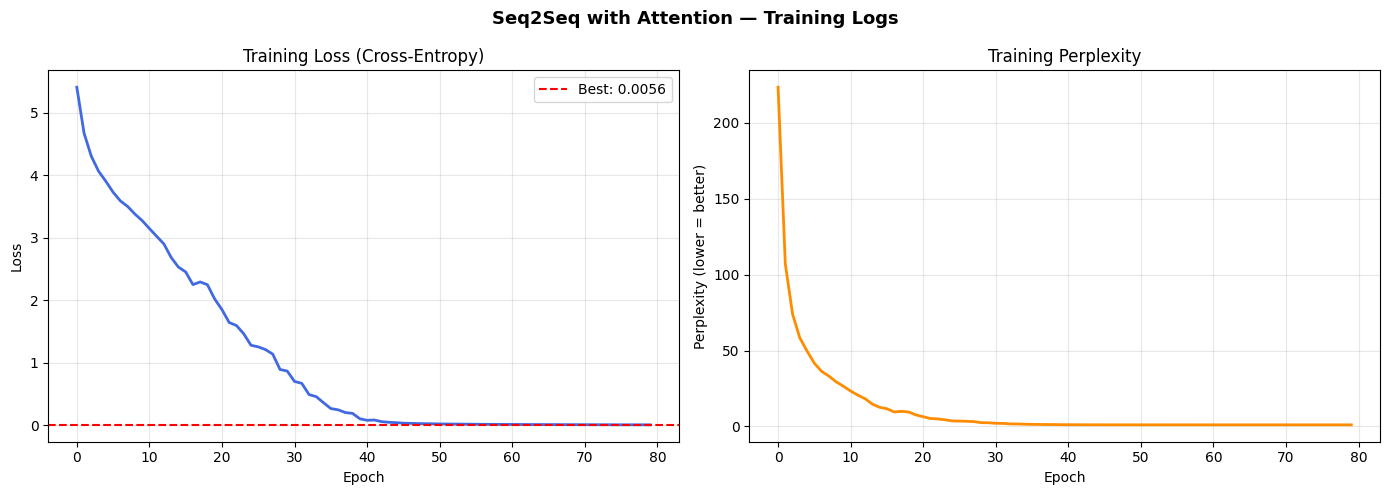

✅ Training log plot saved as training_logs.png


In [10]:
# ── Training Loss Curve ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seq2Seq with Attention — Training Logs', fontsize=13, fontweight='bold')

axes[0].plot(train_losses, color='royalblue', linewidth=2)
axes[0].set_title('Training Loss (Cross-Entropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=best_loss, color='red', linestyle='--',
                label=f'Best: {best_loss:.4f}')
axes[0].legend()

# Perplexity curve
ppls = [math.exp(min(l, 20)) for l in train_losses]
axes[1].plot(ppls, color='darkorange', linewidth=2)
axes[1].set_title('Training Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity (lower = better)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_logs.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Training log plot saved as training_logs.png')

## Step 8: Output Predictions & Attention Visualization

In [11]:
# ── Load best model and generate predictions ──────────────────────────────────
model.load_state_dict(torch.load('best_model_attention.pt', map_location=DEVICE))

def summarize(text, model, vocab, device, max_len=12):
    """Generate a summary for given input text."""
    model.eval()
    src_ids = vocab.encode(text) + [vocab.word2idx[EOS_TOKEN]]
    src     = torch.tensor(src_ids).unsqueeze(0).to(device)
    preds, attn = model.predict(src, max_len=max_len)
    summary = vocab.decode(preds)
    return summary, preds, attn, src_ids

# Test on training examples + new examples
test_texts = [
    "the president signed the new economic bill into law yesterday after months of debate in congress",
    "scientists discovered a new species of deep sea fish in the pacific ocean during a research expedition",
    "the stock market fell sharply on monday due to rising inflation and interest rate concerns",
    "a major earthquake struck the coastal city causing widespread damage and forcing thousands to evacuate",
    "the technology company announced record profits for the third quarter driven by strong smartphone sales",
]
references = [
    "president signs economic bill",
    "new fish species found in pacific",
    "stock market drops amid inflation fears",
    "earthquake hits coastal city thousands evacuate",
    "tech company posts record quarterly profits",
]

print('='*65)
print('PREDICTION OUTPUT — Seq2Seq with Attention')
print('='*65)

all_attn_data = []
bleu_scores   = []
smooth = SmoothingFunction().method1

for i, (text, ref) in enumerate(zip(test_texts, references)):
    summary, preds, attn, src_ids = summarize(text, model, vocab, DEVICE)
    all_attn_data.append((text, summary, attn, src_ids))

    # Compute BLEU-1 score
    reference_tokens = [ref.split()]
    hypothesis_tokens = summary.split()
    if len(hypothesis_tokens) > 0:
        bleu = sentence_bleu(reference_tokens, hypothesis_tokens,
                             smoothing_function=smooth)
    else:
        bleu = 0.0
    bleu_scores.append(bleu)

    print(f'\n[{i+1}] Source   : {text[:70]}...' if len(text)>70 else f'\n[{i+1}] Source   : {text}')
    print(f'    Reference: {ref}')
    print(f'    Generated: {summary}')
    print(f'    BLEU-1   : {bleu:.4f}')

avg_bleu = np.mean(bleu_scores)
print(f'\n{'='*65}')
print(f'Average BLEU-1 Score (with attention): {avg_bleu:.4f}')
print(f'{'='*65}')

PREDICTION OUTPUT — Seq2Seq with Attention

[1] Source   : the president signed the new economic bill into law yesterday after mo...
    Reference: president signs economic bill
    Generated: president signs economic bill
    BLEU-1   : 1.0000

[2] Source   : scientists discovered a new species of deep sea fish in the pacific oc...
    Reference: new fish species found in pacific
    Generated: new fish species found in pacific
    BLEU-1   : 1.0000

[3] Source   : the stock market fell sharply on monday due to rising inflation and in...
    Reference: stock market drops amid inflation fears
    Generated: stock market drops amid inflation fears
    BLEU-1   : 1.0000

[4] Source   : a major earthquake struck the coastal city causing widespread damage a...
    Reference: earthquake hits coastal city thousands evacuate
    Generated: earthquake hits coastal city thousands evacuate
    BLEU-1   : 1.0000

[5] Source   : the technology company announced record profits for the third quarter

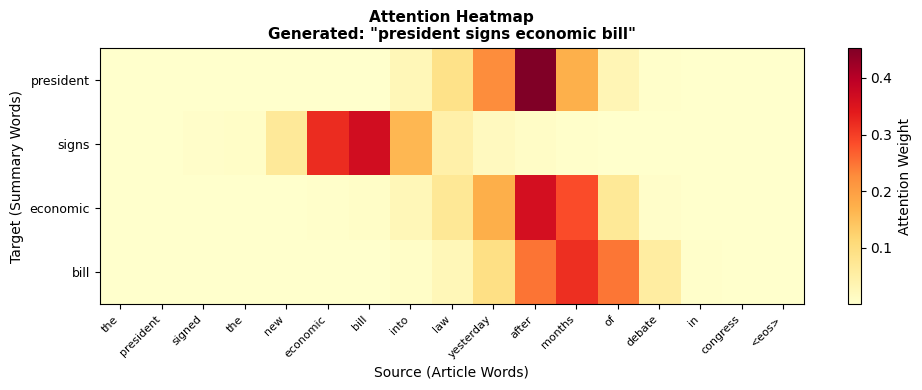

✅ Attention heatmap saved as attention_heatmap.png


In [12]:
# ── Attention Heatmap Visualization ──────────────────────────────────────────
def plot_attention(src_text, tgt_summary, attn_weights_list, src_ids):
    """Visualize attention weights as a heatmap."""
    src_words  = src_text.split() + ['<eos>']
    tgt_words  = tgt_summary.split() if tgt_summary else ['<eos>']

    # Build attention matrix
    n_tgt = min(len(tgt_words), len(attn_weights_list))
    n_src = len(src_ids)

    attn_matrix = np.zeros((n_tgt, n_src))
    for t in range(n_tgt):
        if t < len(attn_weights_list):
            w = attn_weights_list[t]
            if hasattr(w, '__len__'):
                for s in range(min(n_src, len(w))):
                    attn_matrix[t, s] = float(w[s]) if hasattr(w[s], '__float__') else 0

    fig, ax = plt.subplots(figsize=(max(10, n_src//2), max(4, n_tgt)))
    im = ax.imshow(attn_matrix, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n_src))
    ax.set_xticklabels(src_words[:n_src], rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(n_tgt))
    ax.set_yticklabels(tgt_words[:n_tgt], fontsize=9)
    ax.set_xlabel('Source (Article Words)', fontsize=10)
    ax.set_ylabel('Target (Summary Words)', fontsize=10)
    ax.set_title(f'Attention Heatmap\nGenerated: "{tgt_summary}"',
                 fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Attention Weight')
    plt.tight_layout()
    plt.savefig('attention_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()

# Plot attention for first example
src_t, sum_t, attn_t, ids_t = all_attn_data[0]
plot_attention(src_t, sum_t, attn_t, ids_t)
print('✅ Attention heatmap saved as attention_heatmap.png')

## Step 9: Code Structure Summary

| Module | Class | Role | Key Method |
|--------|-------|------|------------|
| encoder | `Encoder` | BiLSTM — encodes source to hidden states | `forward(src)` |
| attention | `BahdanauAttention` | Computes alignment weights + context | `forward(hidden, encoder_out)` |
| decoder | `Decoder` | LSTM — generates target word by word | `forward_step(input, h, c, enc_out)` |
| seq2seq | `Seq2Seq` | Ties encoder + decoder + attention | `forward(src, tgt)` / `predict(src)` |
| training | loop | Backprop + gradient clip + teacher forcing | `train_epoch(...)` |
| evaluation | BLEU | Measures n-gram overlap with reference | `sentence_bleu(...)` |